# Classificação Supervisionada com Fuzzy C-Means no Dataset Adult

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Fuzzy C-Means, aplicado ao dataset Adult. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Fuzzy C-Means.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import skfuzzy as fuzz
import os

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Adult, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados.

In [ ]:
adult_df = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df = adult_df.dropna()
for col in adult_df.select_dtypes(include='object').columns:
    adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop('income', axis=1).values
y = adult_df['income'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Definição do Número de Clusters (Método do Cotovelo)

Utilizamos o método do cotovelo para determinar o número ideal de clusters para o Fuzzy C-Means, usando o coeficiente de partição.

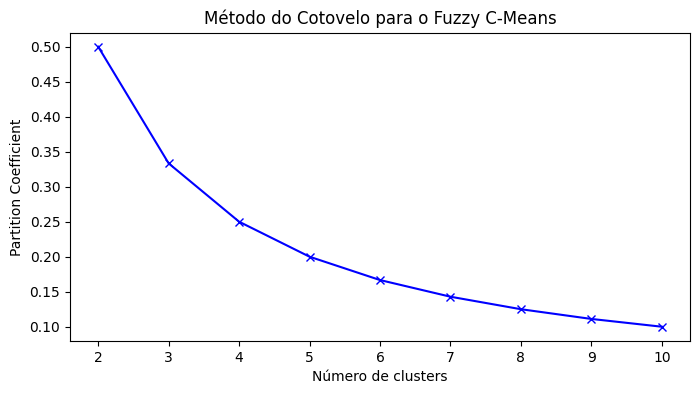

In [ ]:
partition_coeffs = []
K = range(2, 11)
for k in K:
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_train.T, c=k, m=2, error=0.005, maxiter=1000, seed=42)
    pc = np.sum(u ** 2) / u.shape[1]
    partition_coeffs.append(pc)

# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

plt.figure(figsize=(8,4))
plt.plot(K, partition_coeffs, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Partition Coefficient')
plt.title('Método do Cotovelo para o Fuzzy C-Means')
plt.savefig('img/cmeans_adult_elbow.png')
plt.show()

## 5. Implementação do Classificador Fuzzy C-Means Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [ ]:
class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters=2, m=2, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.random_state = random_state
        self.centers_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=0.005, maxiter=1000, seed=self.random_state)
        self.centers_ = cntr
        labels = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (labels == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=0.005, maxiter=1000)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.7592
Matriz de Confusão:
[[7417    0]
 [2352    0]]


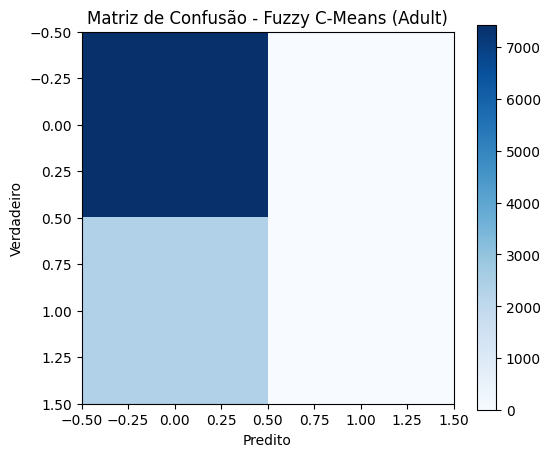

In [ ]:
n_clusters = 2  # Ajuste conforme o gráfico do cotovelo

# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Fuzzy C-Means (Adult)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/cmeans_adult_confusion_matrix.png')
plt.show()

## 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.

Acurácia média: 0.7592
Desvio padrão: 0.0000


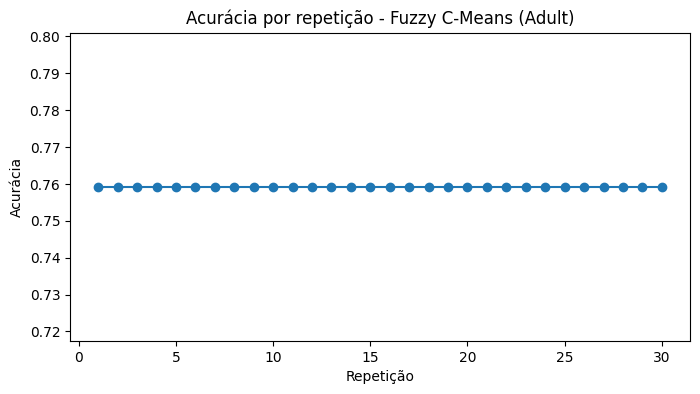

In [ ]:
acuracias = []
# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

acuracias = np.array(acuracias)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Fuzzy C-Means (Adult)')
plt.savefig('img/cmeans_adult_accuracy_repetitions.png')
np.save('img/cmeans_adult_accuracies.npy', acuracias)
np.savetxt('img/cmeans_adult_accuracies.csv', acuracias, delimiter=',')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

mse_array = np.array(mse_list)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - CMeans (Adult)')
plt.savefig('img/cmeans_adult_mse_repetitions.png')
plt.show()

# Salvar MSE para análise posterior
np.save('img/cmeans_adult_mse_repetitions.npy', mse_array)
np.savetxt('img/cmeans_adult_mse_repetitions.csv', mse_array, delimiter=',')

## 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Fuzzy C-Means no dataset Adult.